## Preparation

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import sys
import os

# Method 1: Add the STAligner-master directory to Python path
# This notebook is in Tutorials/, so parent directory is STAligner-master
staligner_root = r'E:\yan0\multi-sample-disentangle\baseline\STAligner-master\STAligner-master'
if os.path.exists(staligner_root) and staligner_root not in sys.path:
    sys.path.insert(0, staligner_root)

import STAligner

import anndata as ad
import scanpy as sc
import pandas as pd
import numpy as np
import scipy.sparse as sp
import scipy.linalg

import torch
used_device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [3]:
import torch_sparse
torch_sparse.__version__

'0.6.18+pt21cu121'

## Load Data

In [16]:
Batch_list = []
adj_list = []

In [22]:
import scanpy as sc

adata = sc.read_h5ad('E:/yan0/multi-sample-disentangle/multi-sample-data/huada/ibd_bin50_merged.h5ad')

sc.pp.filter_genes(adata, min_cells=50)

# Normalization
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, flavor="seurat", n_top_genes=3000)
adata = adata[:, adata.var['highly_variable']]

import scanpy as sc
import matplotlib.pyplot as plt
import math

batch_key = "batch"   # 改成你实际的 batch 列名，如 'slice_name'

# 按 batch 拆分，只取前10个样本
section_ids = sorted(adata.obs[batch_key].astype(str).unique())[:6]
Batch_list = [adata[adata.obs[batch_key].astype(str) == sid].copy() for sid in section_ids]

## Concat the scanpy objects for multiple slices

In [23]:
Batch_list

[AnnData object with n_obs × n_vars = 1389 × 3000
     obs: 'x', 'y', 'group', 'sample', 'chip', 'batch', 'status', 'tissue'
     var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
     uns: 'log1p', 'hvg'
     obsm: 'X_umap', 'spatial',
 AnnData object with n_obs × n_vars = 7781 × 3000
     obs: 'x', 'y', 'group', 'sample', 'chip', 'batch', 'status', 'tissue'
     var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
     uns: 'log1p', 'hvg'
     obsm: 'X_umap', 'spatial',
 AnnData object with n_obs × n_vars = 7559 × 3000
     obs: 'x', 'y', 'group', 'sample', 'chip', 'batch', 'status', 'tissue'
     var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
     uns: 'log1p', 'hvg'
     obsm: 'X_umap', 'spatial',
 AnnData object with n_obs × n_vars = 3504 × 3000
     obs: 'x', 'y', 'group', 'sample', 'chip', 'batch', 'status', 'tissue'
     var: 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_nor

In [24]:
adj_list = []

for section_id, adata_batch in zip(section_ids, Batch_list):
    adata_batch.var_names_make_unique(join="++")
    adata_batch.obs_names = [str(x) + "_" + str(section_id) for x in adata_batch.obs_names]

    STAligner.Cal_Spatial_Net(
        adata_batch,
        rad_cutoff=100,
    )

    adj_list.append(adata_batch.uns["adj"])

------Calculating spatial graph...
The graph contains 9990 edges, 1389 cells.
7.1922 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 54754 edges, 7781 cells.
7.0369 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 56840 edges, 7559 cells.
7.5195 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 26606 edges, 3504 cells.
7.5930 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 45320 edges, 5902 cells.
7.6788 neighbors per cell on average.
------Calculating spatial graph...
The graph contains 51670 edges, 7098 cells.
7.2795 neighbors per cell on average.


In [25]:
adata_concat = ad.concat(Batch_list, label="slice_name", keys=section_ids)
adata_concat.obs['Ground Truth'] = adata_concat.obs['tissue'].astype('category')
adata_concat.obs["batch_name"] = adata_concat.obs["slice_name"].astype('category')
print('adata_concat.shape: ', adata_concat.shape)

adata_concat.shape:  (33233, 3000)


## Concat the spatial network for multiple slices

In [26]:
adj_concat = np.asarray(adj_list[0].todense())
for batch_id in range(1,len(section_ids)):
    adj_concat = scipy.linalg.block_diag(adj_concat, np.asarray(adj_list[batch_id].todense()))
adata_concat.uns['edgeList'] = np.nonzero(adj_concat)

## Running STAligner

In [27]:
%%time
adata_concat = STAligner.train_STAligner(adata_concat, verbose=True, knn_neigh = 50, device=used_device)

STAligner(
  (conv1): GATConv(3000, 512, heads=1)
  (conv2): GATConv(512, 30, heads=1)
  (conv3): GATConv(30, 512, heads=1)
  (conv4): GATConv(512, 3000, heads=1)
)
Pretrain with STAGATE...


100%|██████████| 500/500 [01:23<00:00,  6.00it/s]


Train with STAligner...


  0%|          | 0/500 [00:00<?, ?it/s]

Update spot triplets at epoch 500


...

Update spot triplets at epoch 800


 80%|████████  | 400/500 [02:04<00:19,  5.08it/s]

Update spot triplets at epoch 900


100%|██████████| 500/500 [02:37<00:00,  3.17it/s]


CPU times: total: 4min 5s
Wall time: 4min 3s


In [28]:
adata_concat

AnnData object with n_obs × n_vars = 33233 × 3000
    obs: 'x', 'y', 'group', 'sample', 'chip', 'batch', 'status', 'tissue', 'slice_name', 'Ground Truth', 'batch_name'
    uns: 'edgeList'
    obsm: 'X_umap', 'spatial', 'STAGATE', 'STAligner'

## Clustering

In [31]:
conda install rpy2

Channels:
 - defaults
 - conda-forge
Platform: win-64
Solving environment: ...working... done

## Package Plan ##

  environment location: d:\anaconda3\envs\STAligner

  added / updated specs:
    - rpy2


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    _r-mutex-1.0.0             |      anacondar_1           3 KB
    backports-1.1              |     pyhd3eb1b0_1           6 KB
    backports.zoneinfo-0.2.1   |   py38h2bbff1b_0          52 KB
    cffi-1.17.1                |   py38h827c3e9_0         257 KB
    m2w64-bwidget-1.9.10       |                2         153 KB
    m2w64-bzip2-1.0.6          |                6         100 KB
    m2w64-expat-2.1.1          |                2         160 KB
    m2w64-fftw-3.3.4           |                6         5.4 MB
    m2w64-flac-1.3.1           |                3         872 KB
    m2w64-gettext-0.19.7       |                2         4.2 MB


In [32]:
STAligner.mclust_R(adata_concat, num_cluster=7, used_obsm='STAligner')
adata_concat = adata_concat[adata_concat.obs['Ground Truth']!='unknown']

from sklearn.metrics import adjusted_rand_score as ari_score
print('mclust, ARI = %01.3f' % ari_score(adata_concat.obs['Ground Truth'], adata_concat.obs['mclust']))

ImportError: cannot import name 'zoneinfo' from 'backports' (d:\anaconda3\envs\STAligner\lib\site-packages\setuptools\_vendor\backports\__init__.py)

In [33]:
from sklearn.mixture import GaussianMixture

gmm = GaussianMixture(n_components=7, covariance_type="full", random_state=666)
adata_concat.obs["mclust"] = gmm.fit_predict(adata_concat.obsm["STAligner"]).astype(str)
adata_concat.obs["mclust"] = adata_concat.obs["mclust"].astype("category")

In [34]:
from sklearn.metrics import adjusted_rand_score as ari_score
print('mclust, ARI = %01.3f' % ari_score(adata_concat.obs['Ground Truth'], adata_concat.obs['mclust']))

mclust, ARI = 0.157


## Visualization

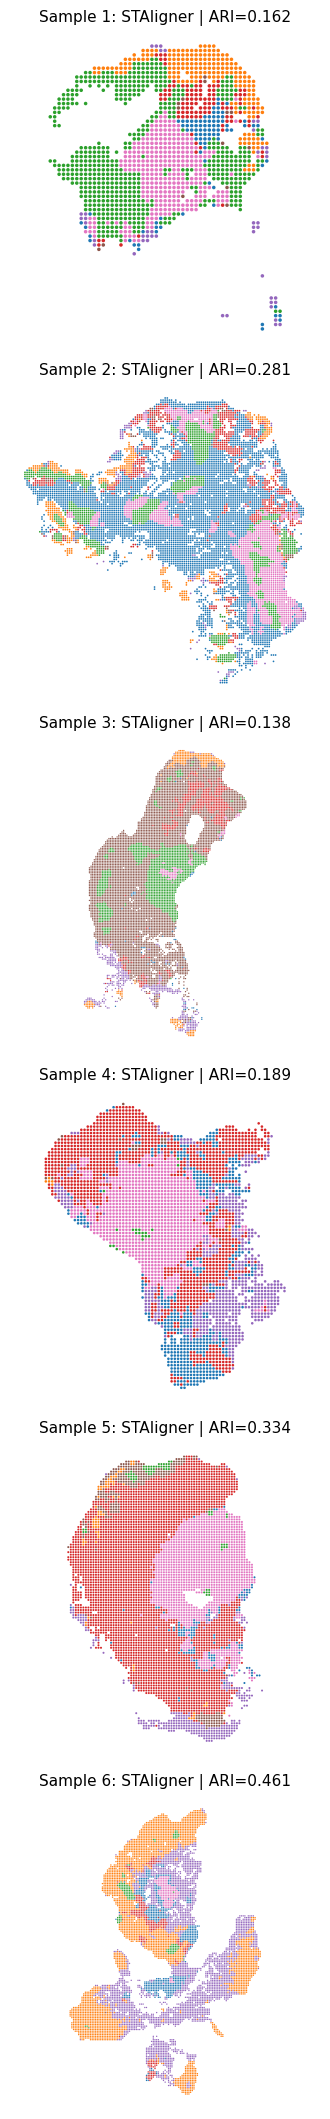

Saved: E:/yan0/multi-sample-disentangle/results/huada/STAligner\all_samples_staligner_clusters.pdf


In [39]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.cm as cm
import scanpy as sc
from sklearn.metrics import adjusted_rand_score as ari_score

if not hasattr(matplotlib.colormaps, "get_cmap"):
    matplotlib.colormaps.get_cmap = cm.get_cmap

spot_sz = 40
cell_type_key = "Ground Truth"
pred_key = "mclust"
batch_key = "batch_name"

save_dir = r"E:/yan0/multi-sample-disentangle/results/huada/STAligner"
os.makedirs(save_dir, exist_ok=True)

sample_ids = sorted(adata_concat.obs[batch_key].astype(str).unique())
adata_results = [
    adata_concat[adata_concat.obs[batch_key].astype(str) == sid].copy()
    for sid in sample_ids
]

n_samples = len(adata_results)
fig, axes = plt.subplots(
    n_samples,
    1,
    figsize=(5, 4.5 * n_samples),
    gridspec_kw={"hspace": 0.12},
)

if n_samples == 1:
    axes = [axes]

for i, ad in enumerate(adata_results):
    valid = (
        ad.obs[cell_type_key].astype(str).ne("unknown")
        & ad.obs[pred_key].notna()
        & ad.obs[cell_type_key].notna()
    )
    ari = ari_score(ad.obs.loc[valid, cell_type_key], ad.obs.loc[valid, pred_key]) if valid.sum() > 0 else np.nan
    title = f"Sample {i+1}: STAligner | ARI={ari:.3f}" if not np.isnan(ari) else f"Sample {i+1}: STAligner"

    img_key = None
    if "spatial" in ad.uns and len(ad.uns["spatial"]) > 0:
        lib = list(ad.uns["spatial"].keys())[0]
        if "images" in ad.uns["spatial"][lib] and "hires" in ad.uns["spatial"][lib]["images"]:
            img_key = "hires"

    sc.pl.spatial(
        ad,
        img_key=img_key,
        color=pred_key,
        ax=axes[i],
        title="",
        legend_loc=None,
        show=False,
        frameon=False,
        spot_size=spot_sz,
    )
    axes[i].set_title(title, fontsize=11)

plt.tight_layout()
out_path = os.path.join(save_dir, "all_samples_staligner_clusters.pdf")
# fig.savefig(out_path, format="pdf", bbox_inches="tight")
plt.show()

print(f"Saved: {out_path}")

In [21]:
import os
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score as ari_score

# 保存到 STAligner 文件夹（不是 Ours）
save_dir = r"E:/yan0/multi-sample-disentangle/results/lung_infected/STAligner/clustering"
os.makedirs(save_dir, exist_ok=True)

Batch_list1 = []
for section_id in section_ids:
    Batch_list1.append(adata_concat[adata_concat.obs["batch_name"] == section_id])

spot_size = 15
title_size = 12

# 计算每个样本 ARI
n_batches = len(Batch_list1)
ARI_list = []
for bb in range(n_batches):
    ARI_list.append(
        round(
            ari_score(
                Batch_list1[bb].obs["Ground Truth"],
                Batch_list1[bb].obs["mclust"],
            ),
            2,
        )
    )

# 分别保存每个 sample 的单图：无 legend + 黑边框
for bb in range(n_batches):
    fig, ax = plt.subplots(1, 1, figsize=(5, 5))

    sc.pl.spatial(
        Batch_list1[bb],
        img_key=None,
        color=["mclust"],
        title=[""],
        legend_loc=None,   # 不显示 legend
        show=False,
        ax=ax,
        frameon=True,      # 开启边框
        spot_size=spot_size,
    )

    # ARI 标题
    # ax.set_title(f"ARI={ARI_list[bb]}", size=title_size)

    # 去坐标轴信息（如要保留可删）
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    # 黑色边框
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
        spine.set_linewidth(1.5)

    out_path = os.path.join(save_dir, f"sample_{bb+1}_mclust.png")
    fig.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

    print(f"Saved: {out_path}")

Saved: E:/yan0/multi-sample-disentangle/results/lung_infected/STAligner/clustering\sample_1_mclust.png
Saved: E:/yan0/multi-sample-disentangle/results/lung_infected/STAligner/clustering\sample_2_mclust.png
Saved: E:/yan0/multi-sample-disentangle/results/lung_infected/STAligner/clustering\sample_3_mclust.png


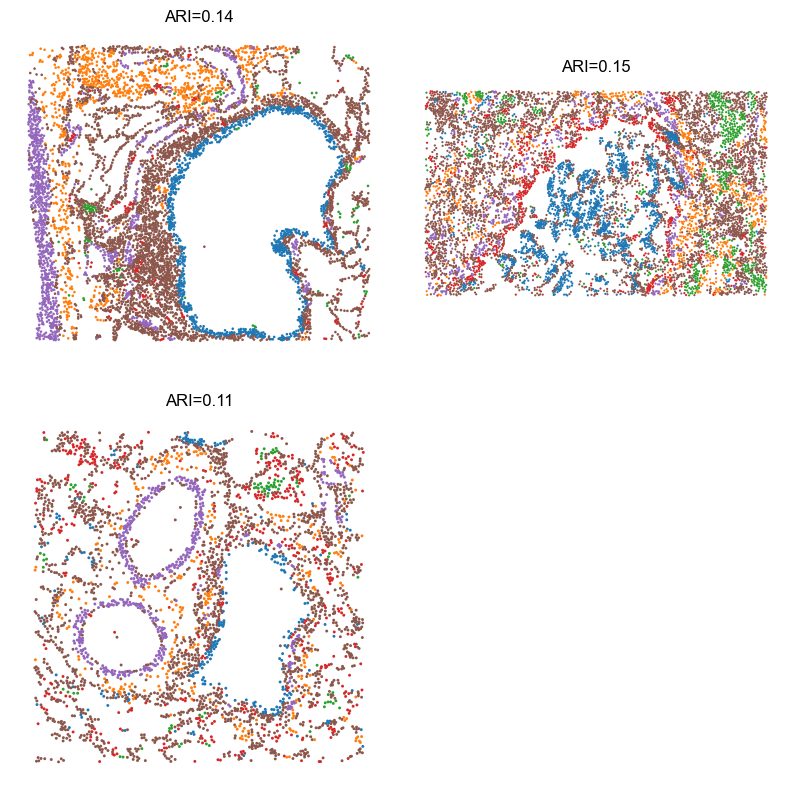

In [17]:
Batch_list1 = []
for section_id in section_ids:
    Batch_list1.append(adata_concat[adata_concat.obs['batch_name'] == section_id])
from sklearn.metrics import adjusted_rand_score as ari_score
import math

import matplotlib.pyplot as plt
spot_size = 15
title_size = 12

# 根据实际数量计算ARI
n_batches = len(Batch_list1)
ARI_list = []
for bb in range(n_batches):
    ARI_list.append(round(ari_score(Batch_list1[bb].obs['Ground Truth'], Batch_list1[bb].obs['mclust']), 2))

# 计算子图布局：固定2列，行数根据数量计算
n_cols = 2
n_rows = math.ceil(n_batches / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 5*n_rows), gridspec_kw={'wspace': 0.05, 'hspace': 0.1})

# 确保axes是二维数组
if n_rows == 1:
    axes = axes.reshape(1, -1)
elif n_cols == 1:
    axes = axes.reshape(-1, 1)

# 绘制每个batch
for bb in range(n_batches):
    row = bb // n_cols
    col = bb % n_cols
    ax = axes[row, col]
    
    _sc = sc.pl.spatial(Batch_list1[bb], img_key=None, color=['mclust'], title=[''],
                        legend_loc=None, legend_fontsize=12, show=False, ax=ax, frameon=False,
                        spot_size=spot_size)
    _sc[0].set_title("ARI=" + str(ARI_list[bb]), size=title_size)

# 隐藏多余的子图
for bb in range(n_batches, n_rows * n_cols):
    row = bb // n_cols
    col = bb % n_cols
    axes[row, col].axis('off')

In [25]:
import os
import numpy as np
import pandas as pd
from sklearn.metrics import adjusted_rand_score as ari_score

# ========= 1) 重新计算每个样本 ARI（不做提前四舍五入） =========
Batch_list1 = [adata_concat[adata_concat.obs["batch_name"] == sid] for sid in section_ids]

ari_values = []
for ad in Batch_list1:
    y_true = ad.obs["Ground Truth"]
    y_pred = ad.obs["mclust"]
    ari_values.append(float(ari_score(y_true, y_pred)))

# ========= 2) 保存到 ari.csv（小数点后 6 位） =========
method_name = "STAligner"
metrics_dir = r"E:\yan0\multi-sample-disentangle\results\lung_infected\metrics"
os.makedirs(metrics_dir, exist_ok=True)
csv_path = os.path.join(metrics_dir, "ari.csv")

# 固定3个样本列，不足补 NaN，超出只取前3个
vals = ari_values[:3] + [np.nan] * max(0, 3 - len(ari_values))

new_row = pd.DataFrame([{
    "method": method_name,
    "sample1_ari": vals[0],
    "sample2_ari": vals[1],
    "sample3_ari": vals[2],
}])

if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    if "method" in df.columns and (df["method"] == method_name).any():
        df.loc[df["method"] == method_name, ["sample1_ari", "sample2_ari", "sample3_ari"]] = vals
    else:
        df = pd.concat([df, new_row], ignore_index=True)
else:
    df = new_row

df.to_csv(csv_path, index=False, encoding="utf-8-sig", float_format="%.6f")

print("Recomputed ARI:", [f"{x:.6f}" for x in ari_values])
print("Saved:", csv_path)

Recomputed ARI: ['0.137995', '0.146806', '0.113410']
Saved: E:\yan0\multi-sample-disentangle\results\lung_infected\metrics\ari.csv
